# Figure 4C Plot Only - Benzethonium With Afatinib

This notebook replots Figure 4C from the saved pathway-reversal score table. The only intentional content change from the previous Figure 4C heatmap is that the benzethonium reference block now includes `afatinib` as an additional observed FDA-approved NSCLC reference drug.

In [1]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------
# Main project folder. Adjust this if your files are elsewhere.
# ---------------------------------------------------------------------
PROJECT_DIR = Path("/work/users/m/e/meisheng/Dissertation/Experiments_Feb152025/code/transformer/Jul7WholeData/Jun2026New/analysis/DrugScreening")

# Output folder used by the original Figure 4 notebook.
OUT_DIR = PROJECT_DIR / "Figure4_MRE269_Benzethonium_repurposing"
TABLE_DIR = OUT_DIR / "tables"
FIG_DIR = OUT_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

# This table is produced by the original notebook after the pathway-reversal scoring step.
# It should contain both focus candidates and all selected FDA-approved NSCLC references,
# including afatinib.
PATHWAY_SCORE_TABLE = TABLE_DIR / "fig4_drug_level_pathway_reversal_scores_long.csv"

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 9,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
})

print("PROJECT_DIR:", PROJECT_DIR)
print("OUT_DIR:", OUT_DIR)
print("PATHWAY_SCORE_TABLE:", PATHWAY_SCORE_TABLE)
print("Pathway score table exists:", PATHWAY_SCORE_TABLE.exists())

PROJECT_DIR: /work/users/m/e/meisheng/Dissertation/Experiments_Feb152025/code/transformer/Jul7WholeData/Jun2026New/analysis/DrugScreening
OUT_DIR: /work/users/m/e/meisheng/Dissertation/Experiments_Feb152025/code/transformer/Jul7WholeData/Jun2026New/analysis/DrugScreening/Figure4_MRE269_Benzethonium_repurposing
PATHWAY_SCORE_TABLE: /work/users/m/e/meisheng/Dissertation/Experiments_Feb152025/code/transformer/Jul7WholeData/Jun2026New/analysis/DrugScreening/Figure4_MRE269_Benzethonium_repurposing/tables/fig4_drug_level_pathway_reversal_scores_long.csv
Pathway score table exists: True


In [2]:
# Figure 4C display pathway order from the full Figure 4 notebook.
SELECTED_HALLMARK_PATHWAYS = [
    "HALLMARK_PI3K_AKT_MTOR_SIGNALING",
    "HALLMARK_MTORC1_SIGNALING",
    "HALLMARK_KRAS_SIGNALING_UP",
    "HALLMARK_KRAS_SIGNALING_DN",
    "HALLMARK_E2F_TARGETS",
    "HALLMARK_G2M_CHECKPOINT",
    "HALLMARK_MYC_TARGETS_V1",
    "HALLMARK_DNA_REPAIR",
    "HALLMARK_P53_PATHWAY",
    "HALLMARK_APOPTOSIS",
    "HALLMARK_HYPOXIA",
    "HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION",
    "HALLMARK_ANGIOGENESIS",
    "HALLMARK_INFLAMMATORY_RESPONSE",
    "HALLMARK_IL6_JAK_STAT3_SIGNALING",
    "HALLMARK_TNFA_SIGNALING_VIA_NFKB",
]

PATHWAY_RENAME = {
    "HALLMARK_PI3K_AKT_MTOR_SIGNALING": "PI3K/AKT/mTOR",
    "HALLMARK_MTORC1_SIGNALING": "mTORC1",
    "HALLMARK_KRAS_SIGNALING_UP": "KRAS up",
    "HALLMARK_KRAS_SIGNALING_DN": "KRAS down",
    "HALLMARK_E2F_TARGETS": "E2F targets",
    "HALLMARK_G2M_CHECKPOINT": "G2M checkpoint",
    "HALLMARK_MYC_TARGETS_V1": "MYC targets",
    "HALLMARK_DNA_REPAIR": "DNA repair",
    "HALLMARK_P53_PATHWAY": "p53 pathway",
    "HALLMARK_APOPTOSIS": "Apoptosis",
    "HALLMARK_HYPOXIA": "Hypoxia",
    "HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION": "EMT",
    "HALLMARK_ANGIOGENESIS": "Angiogenesis",
    "HALLMARK_INFLAMMATORY_RESPONSE": "Inflammatory response",
    "HALLMARK_IL6_JAK_STAT3_SIGNALING": "IL6/JAK/STAT3",
    "HALLMARK_TNFA_SIGNALING_VIA_NFKB": "TNFA/NFKB",
}
PATHWAY_DISPLAY_ORDER = [PATHWAY_RENAME[p] for p in SELECTED_HALLMARK_PATHWAYS]

# Prespecified candidate/reference groups for the revised Figure 4C panel.
# Change: afatinib is inserted into the benzethonium reference block.
FIG4C_REFERENCE_GROUPS = {
    "MRE-269": [
        "crizotinib",
        "methotrexate",
        "gefitinib",
        "everolimus",
        "vinorelbine",
    ],
    "benzethonium": [
        "gemcitabine",
        "afatinib",
        "trametinib",
        "vinorelbine",
    ],
}

In [3]:
def normalize_drug_name(x):
    """Normalize drug names for robust matching across LINCS and annotation tables."""
    if pd.isna(x):
        return np.nan
    x = str(x).strip().lower()
    x = x.translate({0x2013: ord("-"), 0x2014: ord("-"), 0x2212: ord("-")})
    x = re.sub(r"\([^)]*\)", "", x)
    x = re.sub(r"[^a-z0-9]+", "", x)
    aliases = {
        "nvpbez235": "dactolisib",
        "bez235": "dactolisib",
        "gsk2126458": "omipalisib",
        "gdc0941": "pictilisib",
        "mepacrine": "quinacrine",
        "nabpaclitaxel": "paclitaxelalbuminstabilizednanoparticleformulation",
        "abraxane": "paclitaxelalbuminstabilizednanoparticleformulation",
        "taxol": "paclitaxel",
        "taxotere": "docetaxel",
        "alimta": "pemetrexed",
        "gemzar": "gemcitabine",
        "tarceva": "erlotinib",
        "iressa": "gefitinib",
        "xalkori": "crizotinib",
        "tagrisso": "osimertinib",
        "azd9291": "osimertinib",
        "osi774": "erlotinib",
        "pf02341066": "crizotinib",
        "amg510": "sotorasib",
        "mrtx849": "adagrasib",
        "rad001": "everolimus",
    }
    return aliases.get(x, x)


def show_df(df, title=None, n=20):
    if title:
        print(f"\n{title}")
        print("-" * len(title))
    display(df.head(n))
    print("shape:", df.shape)


def save_figure(fig, stem, show=True):
    for ext in ["pdf", "png", "svg"]:
        fig.savefig(FIG_DIR / f"{stem}.{ext}", bbox_inches="tight")
    if show:
        plt.show()
    else:
        plt.close(fig)


def _text_color_for_heatmap_value(value, limit):
    if not np.isfinite(value) or limit <= 0:
        return "black"
    return "white" if abs(value) >= 0.55 * limit else "black"


def _prepare_pathway_scores(path):
    if not Path(path).exists():
        raise FileNotFoundError(
            "Could not find the pathway score table. Update PATHWAY_SCORE_TABLE above, "
            "or rerun the original notebook through the pathway-reversal scoring step. "
            f"Missing path: {path}"
        )
    scores = pd.read_csv(path)
    required_cols = {"source", "pert_iname", "pathway_display", "pathway_reversal_score"}
    missing_cols = sorted(required_cols - set(scores.columns))
    if missing_cols:
        raise ValueError(f"PATHWAY_SCORE_TABLE is missing required columns: {missing_cols}")
    if "drug_key" not in scores.columns:
        scores["drug_key"] = scores["pert_iname"].map(normalize_drug_name)
    else:
        scores["drug_key"] = scores["drug_key"].fillna(scores["pert_iname"].map(normalize_drug_name))
    scores["pathway_reversal_score"] = pd.to_numeric(scores["pathway_reversal_score"], errors="coerce")
    return scores


def _vector_from_scores(scores, source, drug_name, columns):
    key = normalize_drug_name(drug_name)
    sub = scores[
        scores["source"].eq(source)
        & scores["drug_key"].eq(key)
    ].copy()
    if sub.empty:
        return None
    return (
        sub.groupby("pathway_display")["pathway_reversal_score"]
        .mean()
        .reindex(columns)
    )


def _build_group_matrix(scores, candidate_name, reference_names, columns):
    rows = []
    labels = []
    row_types = []

    candidate_vec = _vector_from_scores(
        scores,
        "DEPICT-predicted LINCS",
        candidate_name,
        columns,
    )
    if candidate_vec is None:
        raise ValueError(f"No pathway vector found for candidate: {candidate_name}")

    rows.append(candidate_vec)
    labels.append(candidate_name)
    row_types.append("candidate")

    missing_references = []
    for reference_name in reference_names:
        vec = _vector_from_scores(
            scores,
            "Observed LINCS",
            reference_name,
            columns,
        )
        if vec is None:
            missing_references.append(reference_name)
            continue
        rows.append(vec)
        labels.append(reference_name)
        row_types.append("reference")

    if missing_references:
        raise ValueError(
            "The pathway score table is missing observed pathway rows for: "
            + ", ".join(missing_references)
            + ". Rerun the original notebook through the selected-reference and pathway-reversal scoring steps, "
            "or point PATHWAY_SCORE_TABLE to a score table that includes these references."
        )

    matrix = pd.DataFrame(rows, index=labels, columns=columns)
    metadata = pd.DataFrame({
        "row_label": labels,
        "row_type": row_types,
        "candidate_group": candidate_name,
    })
    return matrix, metadata

In [4]:
def plot_fig4c_focused_candidate_reference_heatmaps(scores, annotate_values=True):
    """
    Plot two vertically stacked Figure 4C heatmaps with a common pathway order and color scale.

    Top panel:
        MRE-269 with crizotinib, methotrexate, gefitinib, everolimus, and vinorelbine.

    Bottom panel:
        benzethonium with gemcitabine, afatinib, trametinib, and vinorelbine.
    """
    available_pathways = set(scores["pathway_display"].dropna().unique())
    columns = [pathway for pathway in PATHWAY_DISPLAY_ORDER if pathway in available_pathways]
    if not columns:
        raise ValueError("No Figure 4C display pathways were found in PATHWAY_SCORE_TABLE.")

    matrices = {}
    metadata_frames = []
    for candidate_name, reference_names in FIG4C_REFERENCE_GROUPS.items():
        matrix, metadata = _build_group_matrix(scores, candidate_name, reference_names, columns)
        matrices[candidate_name] = matrix
        metadata_frames.append(metadata)

    all_values = np.concatenate([
        matrix.to_numpy(dtype=float).ravel()
        for matrix in matrices.values()
    ])
    finite_values = all_values[np.isfinite(all_values)]
    color_limit = (
        max(float(np.nanpercentile(np.abs(finite_values), 95)), 0.25)
        if finite_values.size
        else 1.0
    )

    n_rows_total = sum(matrix.shape[0] for matrix in matrices.values())
    fig_width = 7.3
    fig_height = max(6.9, 2.2 + 0.43 * n_rows_total)

    fig, axes = plt.subplots(
        nrows=2,
        ncols=1,
        figsize=(fig_width, fig_height),
        sharex=True,
        gridspec_kw={
            "height_ratios": [
                matrices["MRE-269"].shape[0],
                matrices["benzethonium"].shape[0],
            ],
            "hspace": 0.26,
        },
    )

    image = None
    panel_labels = {
        "MRE-269": "MRE-269 and prespecified observed NSCLC references",
        "benzethonium": "Benzethonium and prespecified observed NSCLC references",
    }

    for ax, candidate_name in zip(axes, ["MRE-269", "benzethonium"]):
        matrix = matrices[candidate_name]
        values = matrix.to_numpy(dtype=float)

        image = ax.imshow(
            values,
            aspect="auto",
            cmap="coolwarm",
            vmin=-color_limit,
            vmax=color_limit,
        )

        ax.set_yticks(np.arange(matrix.shape[0]))
        ax.set_yticklabels(matrix.index, fontsize=9.0)

        # Bold only the DEPICT candidate row.
        for tick_index, tick_label in enumerate(ax.get_yticklabels()):
            tick_label.set_fontweight("bold" if tick_index == 0 else "normal")

        ax.set_title(
            panel_labels[candidate_name],
            loc="left",
            fontsize=10.5,
            fontweight="bold",
            pad=8,
        )

        # Separate the candidate from its observed references.
        ax.axhline(0.5, color="white", linewidth=2.0)

        if annotate_values:
            for i in range(matrix.shape[0]):
                for j in range(matrix.shape[1]):
                    value = values[i, j]
                    if not np.isfinite(value):
                        continue
                    ax.text(
                        j,
                        i,
                        f"{value:.2f}",
                        ha="center",
                        va="center",
                        fontsize=7.0,
                        color=_text_color_for_heatmap_value(value, color_limit),
                    )

        ax.tick_params(axis="y", length=0)
        for spine in ax.spines.values():
            spine.set_visible(False)

    axes[-1].set_xticks(np.arange(len(columns)))
    axes[-1].set_xticklabels(
        columns,
        rotation=45,
        ha="right",
        fontsize=8,
    )
    axes[-1].set_xlabel("Prespecified NSCLC-relevant Hallmark pathway", fontsize=9.5)

    fig.suptitle(
        "Figure 4C. Candidate pathway-reversal profiles compared with selected FDA-approved NSCLC references",
        x=0.01,
        ha="left",
        fontsize=11.5,
        fontweight="bold",
        y=0.995,
    )

    # Dedicated colorbar axis outside the heatmaps prevents overlap.
    cax = fig.add_axes([0.935, 0.24, 0.018, 0.56])
    cbar = fig.colorbar(image, cax=cax)
    cbar.set_label("Pathway reversal score", fontsize=9)
    cbar.ax.tick_params(labelsize=8)

    fig.subplots_adjust(left=0.20, right=0.90, bottom=0.23, top=0.90)

    stem = "fig4c_focused_candidate_selected_reference_pathway_reversal_heatmaps_with_afatinib"
    save_figure(fig, stem)

    combined_matrix = pd.concat(
        [
            matrix.assign(candidate_group=candidate_name)
            for candidate_name, matrix in matrices.items()
        ],
        axis=0,
    )
    combined_metadata = pd.concat(metadata_frames, ignore_index=True)

    combined_matrix.to_csv(
        TABLE_DIR / "fig4c_focused_candidate_selected_reference_heatmap_matrix_with_afatinib.csv"
    )
    combined_metadata.to_csv(
        TABLE_DIR / "fig4c_focused_candidate_selected_reference_heatmap_row_metadata_with_afatinib.csv",
        index=False,
    )

    print("Saved revised Figure 4C files:")
    for ext in ["pdf", "png", "svg"]:
        print(" -", FIG_DIR / f"{stem}.{ext}")
    print("Saved revised Figure 4C tables:")
    print(" -", TABLE_DIR / "fig4c_focused_candidate_selected_reference_heatmap_matrix_with_afatinib.csv")
    print(" -", TABLE_DIR / "fig4c_focused_candidate_selected_reference_heatmap_row_metadata_with_afatinib.csv")

    return matrices, combined_metadata


Figure 4C required candidate/reference rows
-------------------------------------------


,source,drug,drug_key,candidate_group,matched_pert_iname,n_pathways
0,DEPICT-predicted LINCS,MRE-269,mre269,MRE-269,MRE-269,14
1,Observed LINCS,crizotinib,crizotinib,MRE-269,crizotinib,14
2,Observed LINCS,methotrexate,methotrexate,MRE-269,methotrexate,14
3,Observed LINCS,gefitinib,gefitinib,MRE-269,gefitinib,14
4,Observed LINCS,everolimus,everolimus,MRE-269,everolimus,14
5,Observed LINCS,vinorelbine,vinorelbine,MRE-269,vinorelbine,14
6,DEPICT-predicted LINCS,benzethonium,benzethonium,benzethonium,benzethonium,14
7,Observed LINCS,gemcitabine,gemcitabine,benzethonium,gemcitabine,14
8,Observed LINCS,afatinib,afatinib,benzethonium,afatinib,14
9,Observed LINCS,trametinib,trametinib,benzethonium,trametinib,14


shape: (11, 6)


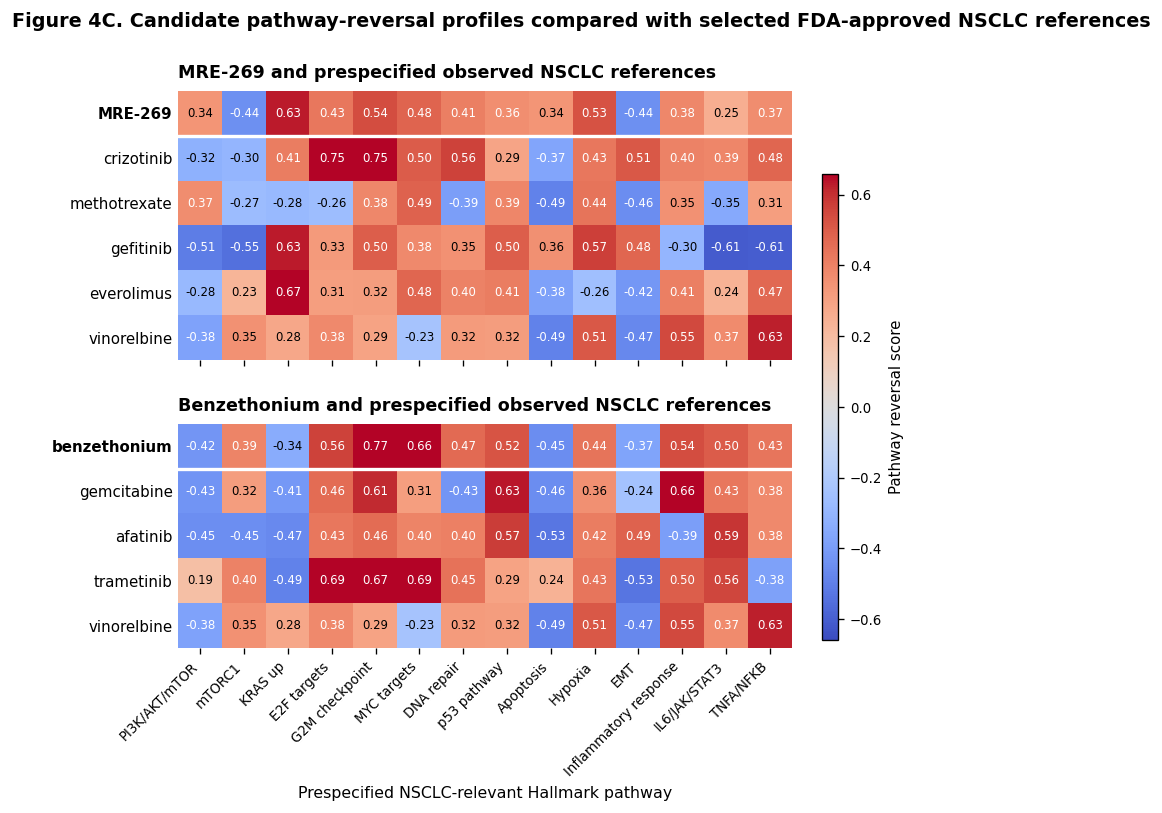

Saved revised Figure 4C files:
 - /work/users/m/e/meisheng/Dissertation/Experiments_Feb152025/code/transformer/Jul7WholeData/Jun2026New/analysis/DrugScreening/Figure4_MRE269_Benzethonium_repurposing/figures/fig4c_focused_candidate_selected_reference_pathway_reversal_heatmaps_with_afatinib.pdf
 - /work/users/m/e/meisheng/Dissertation/Experiments_Feb152025/code/transformer/Jul7WholeData/Jun2026New/analysis/DrugScreening/Figure4_MRE269_Benzethonium_repurposing/figures/fig4c_focused_candidate_selected_reference_pathway_reversal_heatmaps_with_afatinib.png
 - /work/users/m/e/meisheng/Dissertation/Experiments_Feb152025/code/transformer/Jul7WholeData/Jun2026New/analysis/DrugScreening/Figure4_MRE269_Benzethonium_repurposing/figures/fig4c_focused_candidate_selected_reference_pathway_reversal_heatmaps_with_afatinib.svg
Saved revised Figure 4C tables:
 - /work/users/m/e/meisheng/Dissertation/Experiments_Feb152025/code/transformer/Jul7WholeData/Jun2026New/analysis/DrugScreening/Figure4_MRE269_Benze

,row_label,PI3K/AKT/mTOR,mTORC1,KRAS up,E2F targets,G2M checkpoint,MYC targets,DNA repair,p53 pathway,Apoptosis,Hypoxia,EMT,Inflammatory response,IL6/JAK/STAT3,TNFA/NFKB
0,MRE-269,0.342043,-0.444430,0.629489,0.429163,0.539360,0.482002,0.411076,0.362361,0.341330,0.527590,-0.443994,0.382502,0.254117,0.366039
1,crizotinib,-0.320728,-0.298664,0.412934,0.752686,0.749805,0.500379,0.563398,0.291251,-0.366025,0.428444,0.511211,0.397235,0.388981,0.475134
2,methotrexate,0.369830,-0.268104,-0.284041,-0.262604,0.380716,0.488531,-0.392852,0.388588,-0.491099,0.439733,-0.456273,0.353967,-0.353665,0.310901
3,gefitinib,-0.505390,-0.545567,0.627679,0.328758,0.498608,0.380175,0.352749,0.495246,0.358437,0.570519,0.476774,-0.303021,-0.610882,-0.606688
4,everolimus,-0.284416,0.226372,0.671333,0.308948,0.316288,0.478229,0.399066,0.414925,-0.384211,-0.257163,-0.418873,0.411180,0.241131,0.471235
5,vinorelbine,-0.376579,0.351755,0.280937,0.375850,0.294115,-0.234790,0.319081,0.316462,-0.492214,0.513519,-0.471505,0.547484,0.374980,0.626915


shape: (6, 15)

Revised Figure 4C pathway-reversal matrix: benzethonium
-------------------------------------------------------


,row_label,PI3K/AKT/mTOR,mTORC1,KRAS up,E2F targets,G2M checkpoint,MYC targets,DNA repair,p53 pathway,Apoptosis,Hypoxia,EMT,Inflammatory response,IL6/JAK/STAT3,TNFA/NFKB
0,benzethonium,-0.422924,0.394727,-0.339917,0.563690,0.769114,0.655044,0.465155,0.520135,-0.453427,0.437603,-0.371009,0.538129,0.499955,0.434308
1,gemcitabine,-0.430072,0.318179,-0.414902,0.460830,0.610629,0.311787,-0.426547,0.633733,-0.455858,0.358362,-0.237755,0.664853,0.427964,0.376883
2,afatinib,-0.447976,-0.451074,-0.465392,0.429664,0.460771,0.395311,0.401935,0.571592,-0.526233,0.416584,0.487151,-0.392645,0.590895,0.379706
3,trametinib,0.185393,0.400982,-0.492059,0.694575,0.665837,0.685772,0.446665,0.294228,0.237351,0.432768,-0.530199,0.498147,0.555094,-0.380803
4,vinorelbine,-0.376579,0.351755,0.280937,0.375850,0.294115,-0.234790,0.319081,0.316462,-0.492214,0.513519,-0.471505,0.547484,0.374980,0.626915


shape: (5, 15)


In [5]:
pathway_scores = _prepare_pathway_scores(PATHWAY_SCORE_TABLE)

required_records = []
for candidate_name, reference_names in FIG4C_REFERENCE_GROUPS.items():
    required_records.append({
        "source": "DEPICT-predicted LINCS",
        "drug": candidate_name,
        "drug_key": normalize_drug_name(candidate_name),
        "candidate_group": candidate_name,
    })
    for reference_name in reference_names:
        required_records.append({
            "source": "Observed LINCS",
            "drug": reference_name,
            "drug_key": normalize_drug_name(reference_name),
            "candidate_group": candidate_name,
        })
required_df = pd.DataFrame(required_records)

available_df = (
    pathway_scores
    .groupby(["source", "drug_key"], as_index=False)
    .agg(
        matched_pert_iname=("pert_iname", "first"),
        n_pathways=("pathway_reversal_score", lambda x: int(pd.Series(x).notna().sum())),
    )
)
required_check = required_df.merge(available_df, on=["source", "drug_key"], how="left")
show_df(required_check, "Figure 4C required candidate/reference rows", 20)

missing = required_check[required_check["matched_pert_iname"].isna()]
if not missing.empty:
    raise ValueError(
        "Missing required candidate/reference pathway rows: "
        + ", ".join(missing["drug"].tolist())
    )

fig4c_group_matrices, fig4c_group_row_metadata = plot_fig4c_focused_candidate_reference_heatmaps(
    pathway_scores,
    annotate_values=True,
)

for candidate_name, matrix in fig4c_group_matrices.items():
    show_df(
        matrix.reset_index().rename(columns={"index": "row_label"}),
        f"Revised Figure 4C pathway-reversal matrix: {candidate_name}",
        100,
    )